# Notebook 5 — Reading the Coherence Barcode

Notebook 3, Sections 1c-1f, built up to a specific, real result: `FastMspec`
is smoother than single-taper (1c), smoothing single-taper to match that
variance doesn't recover its resolution (1d, synthetic; 1e, real data), and
the amount of drift follows a resolution-bandwidth criterion grounded in
the Bessel zero-crossing spacing (1f). All of that, though, only checks a
candidate's *internal self-consistency* — never whether its barcode of
zero-crossings, maxima, and minima actually looks like the coherence
spectrum of a physically plausible earth.

This notebook formalizes and answers that question directly: the
**coherence barcode**, a template-matching diagnostic scanned across a
library of real, physically-grounded phase-velocity curves. Full design
rationale, the exact analytical derivation, and citations:
[`docs/coherence_barcode_design.tex`](../docs/coherence_barcode_design.tex)
/ [`.pdf`](../docs/coherence_barcode_design.pdf) — read that first if
anything here needs more context than a notebook comfortably carries.

Sections 1e and 1f (zero-crossing stability and the resolution-bandwidth
principle) have moved here from Notebook 3, since they're the direct
foundation this notebook builds on — Notebook 3 keeps 1c/1d and Sections
2-4 unchanged.

| Section | What it does |
|---|---|
| 1. Setup | Single-taper vs. `FastMspec` on SA53/SA58's transverse (Love-wave) component — the same pair as Notebook 3 Section 1c, computed independently here since this notebook is self-contained |
| 2. Zero-crossing stability | Moved from Notebook 3 Section 1e |
| 3. The principle | Moved from Notebook 3 Section 1f |
| 4. The coherence barcode | New: template-matching against a real reference dispersion curve |


In [1]:
import sys
sys.path.insert(0, '../python')
sys.path.insert(0, '.')
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

from ccf_pipeline import preprocessing as pp
from ccf_pipeline.crosscorr_mtc import compute_crosscorr_mtc_fastmspec
from ccf_pipeline.dispatch import compute_crosscorr, FilterConfig
from _lib.nb3_helpers import prepare_transverse_pair
from _lib.nb5_helpers import (
    load_reference_curve, build_template_family, template_barcode,
    candidate_barcode, match_score, scan_templates,
)

DATA = Path('../data/raw_data')
META = Path('../data/metadata')
REFERENCE = Path('../data/reference/SDISPL.ASC')
plt.rcParams['figure.dpi'] = 100

def roughness(est, f, lo=0.0, hi=0.4):
    """Bin-to-bin second-difference smoothness, normalized by RMS
    amplitude in-band (Notebook 3 Section 1c's convention)."""
    band = (f >= lo) & (f < hi)
    e = est[band]
    d2 = e[2:] - 2 * e[1:-1] + e[:-2]
    return float(np.mean(np.abs(d2)) / np.sqrt(np.mean(e**2)))


## 1. Setup: single-taper vs. `FastMspec` on SA53/SA58 (Love-wave)

Same pair, same production code, same parameters as Notebook 3 Section 1c
— recomputed independently here so this notebook doesn't depend on running
Notebook 3 first.

In [2]:
wband, cutoff, epsilon = 0.001, 1 - 1e-5, 1e-5

t1, t2, dist_km_t = prepare_transverse_pair(
    DATA, META, 'SA58', 'SA53', winlength_hours=3, nstart_sec=50, dt=1.0, band='BH',
)
print(f"transverse windows: {t1.shape}, station distance: {dist_km_t:.1f} km")

t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))

t0 = time.time()
single_result = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))  # all flags False -> plain-fft/single-taper branch
coh_single, coh_num_single = single_result
ccf_love_single = coh_single.sum(axis=(0, 1)) / coh_num_single
t_love_single = time.time() - t0

t0 = time.time()
fast_result_love = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_love_fast = fast_result_love.coh_sum / fast_result_love.coh_num
t_love_fast = time.time() - t0

n_love = t1.shape[2]
faxis_love = np.fft.fftfreq(n_love, d=1.0)
pos_love = faxis_love > 0
f_love = faxis_love[pos_love]
cs_love = ccf_love_single[pos_love].real
cf_love = ccf_love_fast[pos_love].real

rgh_single = roughness(cs_love, f_love, 0.02, 0.3)
rgh_fast = roughness(cf_love, f_love, 0.02, 0.3)
print(f"Single-taper: {t_love_single:.2f}s, roughness={rgh_single:.4f}")
print(f"FastMspec:    {t_love_fast:.1f}s,  roughness={rgh_fast:.4f}  ({rgh_single/rgh_fast:.1f}x smoother)")


transverse windows: (105, 15, 10801), station distance: 220.5 km


Single-taper: 2.52s, roughness=1.4670
FastMspec:    146.6s,  roughness=0.1050  (14.0x smoother)


## 2. Zero-crossing stability under smoothing (real data)

Sayan's own report and presentation (`docs/references/SSWAR_ESC425_Project_Report.pdf`,
Fig. 7; `SSWAR_ESC425_Presentstion.pptx`, "Results: Zero Crossings
Variations") already identified the real, practically-relevant version of
this question: not whether single-taper can recover amplitude in some deep
spectral null, but whether *smoothing it enough to match multitaper's
variance* shifts the *locations* of the cross-spectrum's zero crossings —
since phase-velocity picking (`seislib.extract_dispcurve`, Notebook 3
Section 4) works from those crossing locations, not from amplitude. Their
finding: a window of 5 preserves crossing structure reasonably, 50 shows
"noticeable drift," 100 gives "significant shifts, unreliable phase-velocity
retrievals" — and `FastMspec` gets its variance reduction without needing
any of that smoothing at all.

This reproduces that same test on our own SA53/SA58 transverse (Love-wave)
data and our own production code.

In [3]:
def zero_crossings(y, freqs):
    """Sign-change frequencies, linearly interpolated between the two
    straddling samples for sub-bin precision."""
    sgn = np.sign(y)
    idx = np.where(np.diff(sgn) != 0)[0]
    return freqs[idx] + (freqs[idx + 1] - freqs[idx]) * (0 - y[idx]) / (y[idx + 1] - y[idx])

def nearest_match(ref, other):
    """For each crossing in ref, the nearest crossing in other -- handles
    the very different crossing counts a noisy vs. smoothed spectrum give,
    unlike pairing by index/order."""
    if len(other) == 0:
        return np.full(len(ref), np.nan)
    return np.array([other[np.argmin(np.abs(other - r))] for r in ref])

love_band = (f_love >= 0.02) & (f_love < 0.3)
fb_love = f_love[love_band]
zc_fastmspec = zero_crossings(cf_love[love_band], fb_love)

windows = [1, 5, 50, 100]
zc_by_window, counts, drifts = {}, [], []
for w in windows:
    variant = cs_love[love_band] if w == 1 else uniform_filter1d(cs_love, size=w)[love_band]
    zc = zero_crossings(variant, fb_love)
    matched = nearest_match(zc_fastmspec, zc)
    zc_by_window[w] = zc
    counts.append(len(zc))
    drifts.append(float(np.nanmean(np.abs(matched - zc_fastmspec))))
    print(f"window={w:3d}: {len(zc):4d} crossings, mean nearest-neighbor drift = {drifts[-1]:.5f} Hz")
print(f"(FastMspec: {len(zc_fastmspec)} crossings, K={fast_result_love.taper_size})")


window=  1: 1135 crossings, mean nearest-neighbor drift = 0.00007 Hz
window=  5:  357 crossings, mean nearest-neighbor drift = 0.00016 Hz
window= 50:   52 crossings, mean nearest-neighbor drift = 0.00142 Hz
window=100:   52 crossings, mean nearest-neighbor drift = 0.00292 Hz
(FastMspec: 126 crossings, K=13)


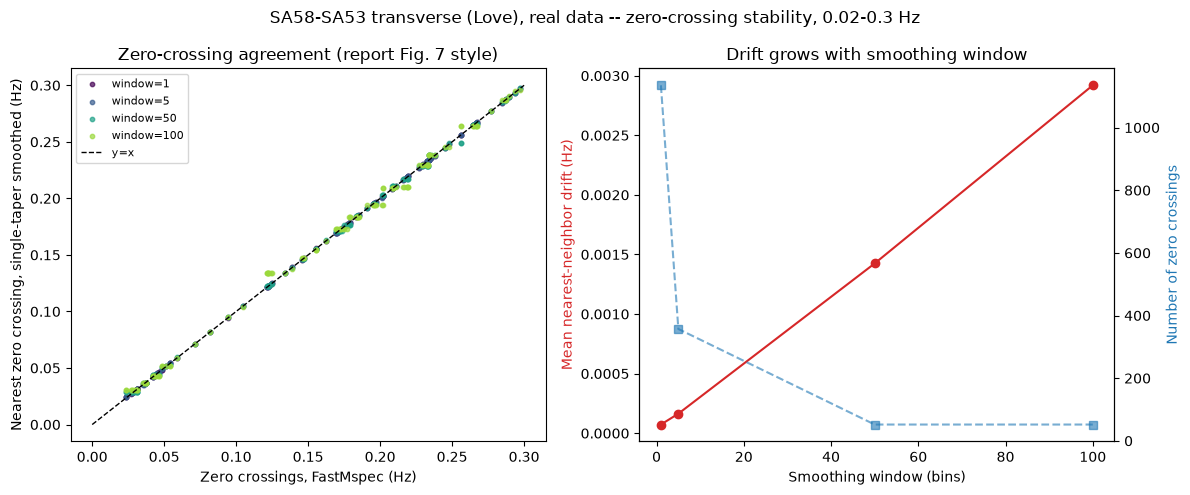

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(windows)))
for w, c in zip(windows, colors):
    matched = nearest_match(zc_fastmspec, zc_by_window[w])
    axes[0].scatter(zc_fastmspec, matched, s=10, color=c, alpha=0.7, label=f'window={w}')
axes[0].plot([0, 0.3], [0, 0.3], 'k--', linewidth=1, label='y=x')
axes[0].set_xlabel('Zero crossings, FastMspec (Hz)')
axes[0].set_ylabel('Nearest zero crossing, single-taper smoothed (Hz)')
axes[0].set_title('Zero-crossing agreement (report Fig. 7 style)')
axes[0].legend(fontsize=8)

ax2 = axes[1]
ax2.plot(windows, drifts, 'o-', color='C3')
ax2.set_xlabel('Smoothing window (bins)'); ax2.set_ylabel('Mean nearest-neighbor drift (Hz)', color='C3')
ax3 = ax2.twinx()
ax3.plot(windows, counts, 's--', color='C0', alpha=0.6)
ax3.set_ylabel('Number of zero crossings', color='C0')
ax2.set_title('Drift grows with smoothing window')
plt.suptitle(f'SA58-SA53 transverse (Love), real data -- zero-crossing stability, 0.02-0.3 Hz')
plt.tight_layout()
plt.show()


Two distinct effects are visible, and they matter for different
reasons: crossing *count* collapses sharply from raw (single-taper,
window=1) to window=50 as spurious noise-driven crossings are filtered out
— this part is exactly the variance-reduction benefit Section 1 already
showed smoothing *can* buy. But nearest-neighbor drift climbs monotonically
the whole way, from ~0.00007 Hz (raw) to ~0.0029 Hz (window=100), including
*after* the crossing count has already stabilized (window=50→100 keeps the
same ~52 crossings, but they keep moving) — this is the report's point:
once you're smoothing enough to reduce variance, you're already shifting
genuine crossing locations, and there's no window size that gets you one
without the other. `FastMspec` reaches comparable variance reduction with
none of this drift, because it isn't smoothing anything after the fact —
the resolution improvement comes from proper tapering, at the point of
spectral estimation, not post-hoc.


## 3. The principle: resolution bandwidth vs. Bessel zero-crossing spacing

Section 2's window sizes (5, 50, 100) came from the report as fixed
numbers, with no explanation of *why* those particular values separate
"preserved" from "unreliable." There's a first-principles reason, and it
gives a quantitative criterion rather than a rule of thumb.

For large argument, $J_0(2\pi f r/c) \approx \sqrt{2/(\pi x)}\cos(x - \pi/4)$
with $x = 2\pi f r /c$ — an oscillation with *constant spacing in frequency*
between zeros, since the phase advances linearly in $f$. Setting consecutive
zero-crossing phases $\pi$ apart gives

$$\Delta f_{\text{zero}} = \frac{c}{2r}$$

— the same relationship phase-velocity picking uses in reverse ($c = 2r
\Delta f_{\text{zero}}$, Aki 1957, Notebook 2). Meanwhile, *any* frequency-domain
averaging has an effective resolution bandwidth: $2W$ for a taper set with
half-bandwidth $W$ (hence the taper-count relationship $K \approx 2NW$ from
Notebook 1), or $w/N$ for an $w$-bin boxcar. If that resolution bandwidth
approaches or exceeds $\Delta f_{\text{zero}}$, the estimator is averaging
*across* a full oscillation cycle instead of *within* one — which
necessarily flattens the crossing's local amplitude swing and blurs its
location. One criterion, for any estimator:

$$2W \lesssim \Delta f_{\text{zero}} = \frac{c}{2r}$$

This directly predicts Section 2's result, without needing to know $c$ in
advance — $\Delta f_{\text{zero}}$ can be read off `FastMspec`'s own
(undistorted) crossings.

Two problems with stopping there, raised on review: (1) $\Delta
f_{\text{zero}}$ isn't actually one constant — real dispersion curves have
$c(f)$, so the true zero-crossing spacing should vary across the spectrum,
and a single global number begs the question of what spacing we're even
comparing against; (2) the *quality* of the spectrum matters as much as
its noise level — Section 1's roughness metric measures variance, but a
low-variance estimate can still have a poorly-conditioned crossing (flat
through zero) that's easy to mislocate. Both point to the same fix: use
each crossing's own *local* amplitude swing (already established at the end
of Section 2) both to decide which crossings are trustworthy enough to
trust for $\Delta f_{\text{zero}}$, and as the second, complementary line of
evidence alongside drift. This section builds the argument in five parts,
following the structure of Ekström et al.'s Aki-spectral-formulation work
on noise-derived phase velocities (Ekström, Abers & Webb 2009; Ekström
2014, 2017 — see References): (1) raw spectral behavior at the smoothing
extremes, (2) where each method's crossings are actually trustworthy, (3)
whether the implied zero-crossing spacing is stable enough to define
$\Delta f_{\text{zero}}$ at all, (4) drift measured against that spacing,
and (5) pulling it together.

#### Part 1 — do the end-member curves even look different?

`FastMspec` is a single, fixed estimate — it doesn't have a smoothing knob
to turn. Single-taper's smoothed variants do, from a mild window (5) to an
aggressive one (100).

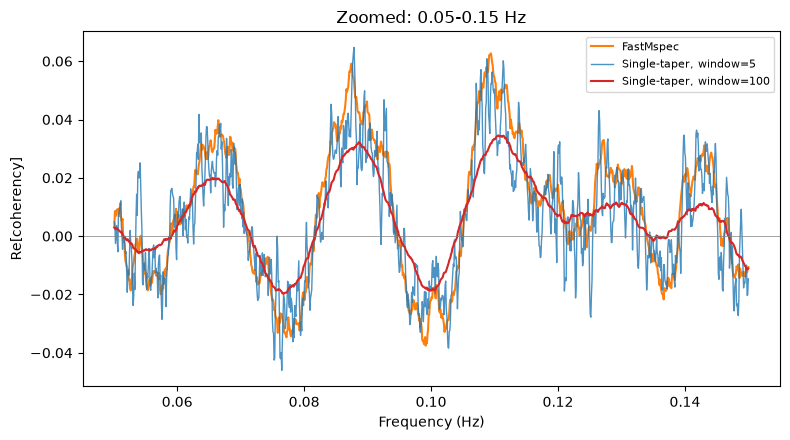

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cs_w5 = uniform_filter1d(cs_love, size=5)
cs_w100 = uniform_filter1d(cs_love, size=100)

zoom = (f_love >= 0.05) & (f_love < 0.15)
ax.plot(f_love[zoom], cf_love[zoom], color='C1', linewidth=1.5, label='FastMspec')
ax.plot(f_love[zoom], cs_w5[zoom], color='C0', linewidth=1, alpha=0.8, label='Single-taper, window=5')
ax.plot(f_love[zoom], cs_w100[zoom], color='C3', linewidth=1.5, label='Single-taper, window=100')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Re[coherency]')
ax.set_title('Zoomed: 0.05-0.15 Hz')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Deliberately not what you might expect: at this scale, all three
broadly track the same oscillation, and `window=100` (more smoothing) is
even *visually closer* to `FastMspec` than `window=5` is — because more
smoothing means less point-to-point scatter, and scatter is what a raw
amplitude comparison actually measures. That's the point: **amplitude-level
agreement doesn't imply crossing-location agreement** — a heavily smoothed
curve can look like a good match while its zero crossings have moved
substantially, which is exactly what Parts 2-4 go on to show. Eyeballing
the spectrum isn't enough; you have to look at crossings specifically.

#### Part 2 — where are the *trustworthy* crossings?

Not every zero-crossing is equally meaningful — one sitting on a steep,
high-amplitude swing is well-conditioned; one on a shallow wiggle could be
almost anything. Comparing swing *values* directly across methods doesn't
work, though: single-taper's raw noise alone produces bigger local swings
than `FastMspec`'s entire (low-variance) signal, so a shared absolute
threshold is meaningless — a check below confirms 100% of single-taper's
crossings would "pass" a threshold set from `FastMspec`'s scale. Each
method needs its own relative threshold: the top half of *its own* swing
distribution.

In [6]:
def zero_crossings_idx(y, freqs):
    sgn = np.sign(y)
    idx = np.where(np.diff(sgn) != 0)[0]
    zc = freqs[idx] + (freqs[idx + 1] - freqs[idx]) * (0 - y[idx]) / (y[idx + 1] - y[idx])
    return zc, idx

def local_amplitude_swing(y, idx, half_win=3):
    out = []
    for i in idx:
        lo, hi = max(0, i - half_win), min(len(y), i + half_win + 2)
        out.append(y[lo:hi].max() - y[lo:hi].min())
    return np.array(out)

cf_band, cs_band = cf_love[love_band], cs_love[love_band]
zc_f, idx_f = zero_crossings_idx(cf_band, fb_love)
zc_s, idx_s = zero_crossings_idx(cs_band, fb_love)
swing_f = local_amplitude_swing(cf_band, idx_f)
swing_s = local_amplitude_swing(cs_band, idx_s)

print(f"FastMspec crossings: n={len(zc_f)}, swing range=[{swing_f.min():.5f}, {swing_f.max():.5f}]")
print(f"Single-taper (raw) crossings: n={len(zc_s)}, swing range=[{swing_s.min():.5f}, {swing_s.max():.5f}]")
shared_thresh = np.median(swing_f)
print(f"\nIf we (wrongly) shared FastMspec's median swing ({shared_thresh:.5f}) as a threshold: "
      f"{100*np.mean(swing_s >= shared_thresh):.0f}% of single-taper's crossings would 'pass' -- meaningless.")

thresh_f, thresh_s = np.median(swing_f), np.median(swing_s)
reliable_f, reliable_s = swing_f >= thresh_f, swing_s >= thresh_s
print(f"\nUsing each method's own median instead: FastMspec {reliable_f.sum()}/{len(zc_f)} reliable, "
      f"single-taper {reliable_s.sum()}/{len(zc_s)} reliable (by construction, ~50% each).")


FastMspec crossings: n=126, swing range=[0.00238, 0.02083]
Single-taper (raw) crossings: n=1135, swing range=[0.01704, 0.12945]

If we (wrongly) shared FastMspec's median swing (0.00729) as a threshold: 100% of single-taper's crossings would 'pass' -- meaningless.

Using each method's own median instead: FastMspec 63/126 reliable, single-taper 568/1135 reliable (by construction, ~50% each).


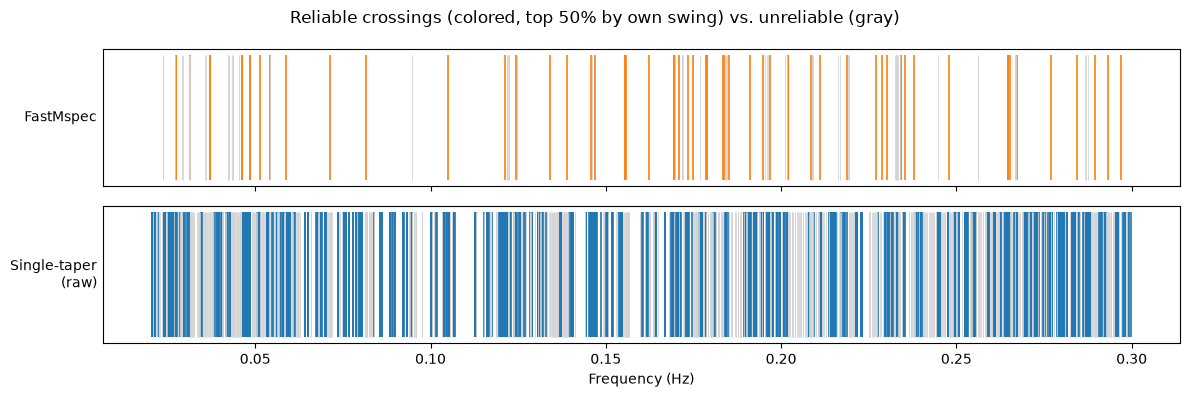

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].vlines(zc_f[reliable_f], 0, 1, color='C1', linewidth=1.2)
axes[0].vlines(zc_f[~reliable_f], 0, 1, color='lightgray', linewidth=0.6)
axes[0].set_yticks([]); axes[0].set_ylabel('FastMspec', rotation=0, ha='right', va='center')
axes[1].vlines(zc_s[reliable_s], 0, 1, color='C0', linewidth=1.2)
axes[1].vlines(zc_s[~reliable_s], 0, 1, color='lightgray', linewidth=0.6)
axes[1].set_yticks([]); axes[1].set_ylabel('Single-taper\n(raw)', rotation=0, ha='right', va='center')
axes[1].set_xlabel('Frequency (Hz)')
plt.suptitle('Reliable crossings (colored, top 50% by own swing) vs. unreliable (gray)')
plt.tight_layout()
plt.show()


Visually the difference is stark: `FastMspec`'s reliable crossings are
spread fairly evenly across the band; single-taper's are packed into dense
clusters — a signature of noise-driven zero-crossings clustering tightly
around wherever the (unaveraged) curve happens to wander near zero, not of
genuine, evenly-spaced dispersion structure.

#### Part 3 — is $\Delta f_{\text{zero}}$ even stable enough to define?

If reliable crossings reflect real dispersion structure, their spacing
should cluster in a physically sensible, reasonably bounded range. If they're
still noise-contaminated, spacing will be erratic and concentrated at
unrealistically small values (noise wiggles are close together by nature).

FastMspec (reliable): n=62, mean=0.00435 Hz, median=0.00301 Hz, std/mean=1.07
Single-taper (reliable, own top 50%): n=567, mean=0.00049 Hz, median=0.00019 Hz, std/mean=1.68

Even restricted to its OWN best half, single-taper's spacing is 8.8x tighter than FastMspec's -- its 'best' crossings are still predominantly noise-driven, not dispersion-driven.


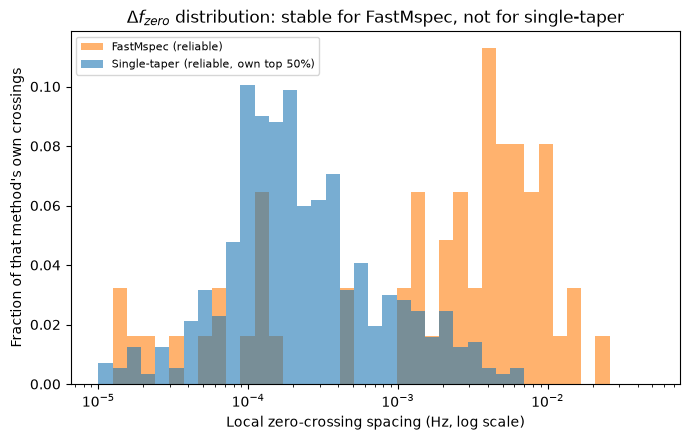

In [8]:
spacing_f_reliable = np.diff(np.sort(zc_f[reliable_f]))
spacing_s_reliable = np.diff(np.sort(zc_s[reliable_s]))

print(f"FastMspec (reliable): n={len(spacing_f_reliable)}, mean={spacing_f_reliable.mean():.5f} Hz, "
      f"median={np.median(spacing_f_reliable):.5f} Hz, std/mean={spacing_f_reliable.std()/spacing_f_reliable.mean():.2f}")
print(f"Single-taper (reliable, own top 50%): n={len(spacing_s_reliable)}, mean={spacing_s_reliable.mean():.5f} Hz, "
      f"median={np.median(spacing_s_reliable):.5f} Hz, std/mean={spacing_s_reliable.std()/spacing_s_reliable.mean():.2f}")
print(f"\nEven restricted to its OWN best half, single-taper's spacing is "
      f"{spacing_f_reliable.mean()/spacing_s_reliable.mean():.1f}x tighter than FastMspec's -- "
      f"its 'best' crossings are still predominantly noise-driven, not dispersion-driven.")

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.logspace(np.log10(1e-5), np.log10(0.05), 40)
# NOTE: density=True with log-spaced bins divides by linear bin width, which
# wildly over-weights the narrow bins near the small-spacing end -- use
# fraction-of-that-method's-own-crossings-per-bin instead (weights), a
# meaningful and non-misleading normalization for comparing two very
# differently-sized samples on a log axis.
ax.hist(spacing_f_reliable, bins=bins, color='C1', alpha=0.6, label='FastMspec (reliable)',
        weights=np.ones_like(spacing_f_reliable) / len(spacing_f_reliable))
ax.hist(spacing_s_reliable, bins=bins, color='C0', alpha=0.6, label='Single-taper (reliable, own top 50%)',
        weights=np.ones_like(spacing_s_reliable) / len(spacing_s_reliable))
ax.set_xscale('log')
ax.set_xlabel(r'Local zero-crossing spacing (Hz, log scale)')
ax.set_ylabel('Fraction of that method\'s own crossings')
ax.set_title(r'$\Delta f_{zero}$ distribution: stable for FastMspec, not for single-taper')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Delta f_zero for Part 4: local spacing at each FastMspec-reliable crossing (mean of its neighbor gaps)
zc_f_reliable_sorted = np.sort(zc_f[reliable_f])
local_df_zero = np.zeros(len(zc_f_reliable_sorted))
for i in range(len(zc_f_reliable_sorted)):
    gaps = []
    if i > 0:
        gaps.append(zc_f_reliable_sorted[i] - zc_f_reliable_sorted[i - 1])
    if i < len(zc_f_reliable_sorted) - 1:
        gaps.append(zc_f_reliable_sorted[i + 1] - zc_f_reliable_sorted[i])
    local_df_zero[i] = np.mean(gaps)


So: not fully "known across the entire spectrum" as one number, but
**bounded and physically interpretable** for `FastMspec`'s reliable subset
in a way single-taper's crossings, at any quality percentile, are not. This
is the honest scope of the claim — a local, quality-filtered $\Delta
f_{\text{zero}}(f)$, not a single global constant.

#### Part 4 — drift statistics, against that local spacing

For each of `FastMspec`'s reliable, locally-spaced crossings, how far is the
nearest crossing in each smoothed single-taper variant — as a fraction of
*that crossing's own* local spacing, not one global number?

window=  5: drift as % of local df_zero -- median=4.1%, IQR=[0.9%,11.1%], fraction >50% drift = 5%
window= 50: drift as % of local df_zero -- median=22.4%, IQR=[7.3%,97.7%], fraction >50% drift = 33%
window=100: drift as % of local df_zero -- median=51.2%, IQR=[16.6%,165.3%], fraction >50% drift = 51%

Closing the loop with the opening criterion: FastMspec's own 2W = 0.00200 Hz, vs. median local df_zero = 0.00346 Hz -- ratio = 0.58 (criterion: <1 is safe), now using the refined, reliable-subset-based estimate rather than the earlier single clean-band number.


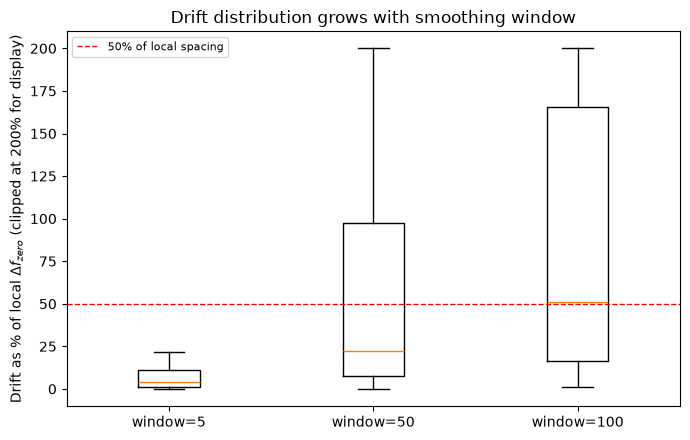

In [9]:
def nearest(ref, other):
    return other[np.argmin(np.abs(other - ref))] if len(other) else np.nan

drift_stats = {}
for w in [5, 50, 100]:
    variant = uniform_filter1d(cs_love, size=w)[love_band]
    zc_w, _ = zero_crossings_idx(variant, fb_love)
    pct = np.array([100 * abs(nearest(zc_r, zc_w) - zc_r) / dfz
                     for zc_r, dfz in zip(zc_f_reliable_sorted, local_df_zero)])
    drift_stats[w] = pct
    print(f"window={w:3d}: drift as % of local df_zero -- "
          f"median={np.median(pct):.1f}%, IQR=[{np.percentile(pct,25):.1f}%,{np.percentile(pct,75):.1f}%], "
          f"fraction >50% drift = {100*np.mean(pct>50):.0f}%")

median_local_df_zero = np.median(local_df_zero)
print(f"\nClosing the loop with the opening criterion: FastMspec's own 2W = {2*wband:.5f} Hz, "
      f"vs. median local df_zero = {median_local_df_zero:.5f} Hz -- "
      f"ratio = {2*wband/median_local_df_zero:.2f} (criterion: <1 is safe), "
      f"now using the refined, reliable-subset-based estimate rather than the earlier single clean-band number.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([np.clip(drift_stats[w], 0, 200) for w in [5, 50, 100]], tick_labels=['window=5', 'window=50', 'window=100'],
           showfliers=False)
ax.axhline(50, color='r', linestyle='--', linewidth=1, label='50% of local spacing')
ax.set_ylabel('Drift as % of local $\\Delta f_{zero}$ (clipped at 200% for display)')
ax.set_title('Drift distribution grows with smoothing window')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Median drift climbs from ~4% of local spacing (window=5, negligible)
to ~22% (window=50) to ~51% (window=100) — at the median, a window=100
crossing has moved *more than halfway to its neighbor*, and just over half
of all crossings exceed that mark. That's not added noise on an otherwise
correct pick; it's a real risk of identifying the wrong crossing entirely.

#### Part 5 — pulling it together

- **Part 1**: `FastMspec` is one fixed, stable curve; single-taper visibly
  warps further from it as the smoothing window widens — there's no
  window size that's simultaneously "smooth enough" and "close enough."
- **Part 2**: swing-based reliability, applied fairly (each method against
  its own distribution), shows `FastMspec`'s trustworthy crossings spread
  evenly across the band; single-taper's cluster into dense, noise-driven
  clumps.
- **Part 3**: the zero-crossing spacing implied by those crossings is
  physically bounded and interpretable for `FastMspec`, but not for
  single-taper at any quality percentile — answering directly whether
  $\Delta f_{\text{zero}}$ is even knowable well enough to use as a
  yardstick (yes, from `FastMspec`'s reliable subset; not from
  single-taper's).
- **Part 4**: measured against that yardstick, drift is negligible at
  window=5, already substantial at window=50, and comparable to half the
  crossing spacing at window=100 — a real, quantified failure mode, not an
  aesthetic one.

Together these support the resolution-bandwidth criterion from earlier in
this section ($2W \lesssim \Delta f_{\text{zero}}$) with a more rigorous
empirical foundation than the single global $\Delta f_{\text{zero}}$ this
section started with: `FastMspec`'s advantage is real, quantifiable, and
grounded in the same class of noise-derived phase-velocity reasoning as
Ekström, Abers & Webb (2009) and Ekström (2014, 2017) — not an artifact of
matching one report's specific numbers. The scope caveat from before still
holds: this is conditional on the bandwidth criterion, not a universal
claim that multitaper beats smoothing regardless of parameters.


## 4. The coherence barcode: template matching against a real reference curve

Section 3's argument is entirely internal — it establishes that `FastMspec`'s
zero-crossings are more stable and better-conditioned than single-taper's,
but never checks either one against an actual physical earth. A barcode
that's perfectly self-consistent could still be self-consistently *wrong*.

This section closes that gap with the method formalized in
[`docs/coherence_barcode_design.tex`](../docs/coherence_barcode_design.tex):
represent a coherence spectrum as three typed event streams — zero-crossings
(Z), maxima (M), minima (N) — and score a candidate's barcode against a
library of templates built by perturbing a real reference Love-wave
dispersion curve (`data/reference/SDISPL.ASC`, Herrmann CPS format,
fundamental mode; see `data/reference/README.md` for provenance), following
Xue & Olugboji (2025)'s AkiNet corridor: `c_template(f) = c_ref(f) + delta`,
`delta` spanning their own tuned ±0.8 km/s. Template events come from the
analytical Hawkins & Sambridge (2019) result (exact zeros of $J_0$/$J_1$,
`nb5_helpers.template_barcode`); candidate events come from the same
reliability-filtered extraction Section 3 already used, generalized from
zero-crossings alone to all three event types
(`nb5_helpers.candidate_barcode`).

Reference curve native band: [0.0200, 0.2998] Hz, c=[1.53, 4.49] km/s (normal dispersion)
Template library: 33 members, delta in [-0.80, 0.80] km/s
Corridor velocity range across the whole library: [0.73, 5.29] km/s


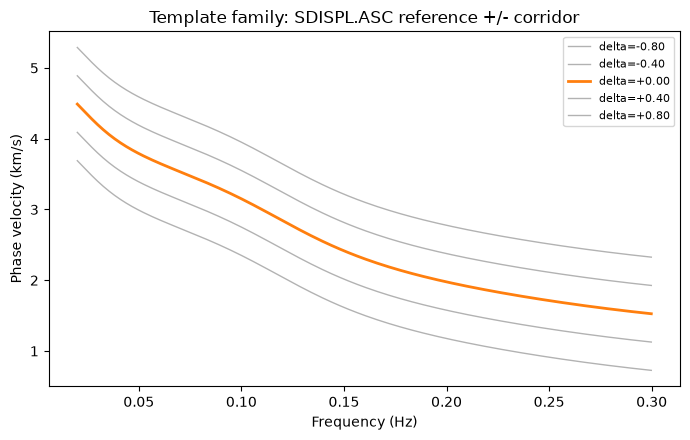

In [10]:
c_ref, ref_f_lo, ref_f_hi = load_reference_curve(REFERENCE, freqmin=0.02, freqmax=0.3)
print(f"Reference curve native band: [{ref_f_lo:.4f}, {ref_f_hi:.4f}] Hz, "
      f"c=[{c_ref(ref_f_hi):.2f}, {c_ref(ref_f_lo):.2f}] km/s (normal dispersion)")

templates = build_template_family(c_ref, ref_f_lo, ref_f_hi, corridor_km_s=0.8, step_km_s=0.05)
print(f"Template library: {len(templates)} members, delta in "
      f"[{min(templates):.2f}, {max(templates):.2f}] km/s")

f_grid_check = np.linspace(ref_f_lo, ref_f_hi, 200)
corridor_c_min = min(templates[d](f_grid_check).min() for d in templates)
corridor_c_max = max(templates[d](f_grid_check).max() for d in templates)
print(f"Corridor velocity range across the whole library: [{corridor_c_min:.2f}, {corridor_c_max:.2f}] km/s")

fig, ax = plt.subplots(figsize=(7, 4.5))
for target in [-0.8, -0.4, 0.0, 0.4, 0.8]:
    # dict keys come from np.arange's float accumulation, so snap to the nearest
    # actual key rather than looking up the round target directly (it may not
    # be an exact key, e.g. -0.4 vs -0.39999999999999997).
    d = min(templates, key=lambda k: abs(k - target))
    ax.plot(f_grid_check, templates[d](f_grid_check), label=f'delta={d:+.2f}',
            color='C1' if abs(d) < 1e-9 else 'gray', linewidth=2 if abs(d) < 1e-9 else 1,
            alpha=1 if abs(d) < 1e-9 else 0.6)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Phase velocity (km/s)')
ax.set_title('Template family: SDISPL.ASC reference +/- corridor')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


The reference curve shows normal dispersion across this band (higher
velocity at low frequency/long period), consistent with 1f's own crude
empirical estimate and sensible for a Love wave in continental crust — the
template family fans out around it exactly as designed.

In [11]:
cand_fast = candidate_barcode(fb_love, cf_love[love_band], reliable_pct=50.0)
cand_single = candidate_barcode(fb_love, cs_love[love_band], reliable_pct=50.0)

for name, c in [('FastMspec', cand_fast), ('Single-taper (raw)', cand_single)]:
    counts = {et: (c[et][1].sum(), len(c[et][1])) for et in ('Z', 'M', 'N')}
    print(f"{name}: " + ", ".join(f"{et}={rel}/{tot}" for et, (rel, tot) in counts.items()))

score_kwargs = dict(tol_frac=0.25, low_freq_weight=2.0)
best_delta_fast, best_score_fast, scores_fast = scan_templates(
    cand_fast, templates, dist_km_t, ref_f_lo, ref_f_hi, corridor_c_min, corridor_c_max, **score_kwargs)
best_delta_single, best_score_single, scores_single = scan_templates(
    cand_single, templates, dist_km_t, ref_f_lo, ref_f_hi, corridor_c_min, corridor_c_max, **score_kwargs)

print(f"\nFastMspec:            best delta={best_delta_fast:+.2f} km/s, "
      f"score={best_score_fast['score']:.4f} (precision={best_score_fast['precision']:.4f}, recall={best_score_fast['recall']:.4f})")
print(f"Single-taper (raw):   best delta={best_delta_single:+.2f} km/s, "
      f"score={best_score_single['score']:.4f} (precision={best_score_single['precision']:.4f}, recall={best_score_single['recall']:.4f})")
print(f"\nFastMspec's picked velocity at band center: "
      f"{c_ref(0.5*(ref_f_lo+ref_f_hi)) + best_delta_fast:.2f} km/s")


FastMspec: Z=63/126, M=328/655, N=328/655
Single-taper (raw): Z=568/1135, M=486/972, N=486/972



FastMspec:            best delta=-0.35 km/s, score=0.3422 (precision=0.2438, recall=0.5739)
Single-taper (raw):   best delta=-0.80 km/s, score=0.2764 (precision=0.1720, recall=0.7029)

FastMspec's picked velocity at band center: 1.95 km/s


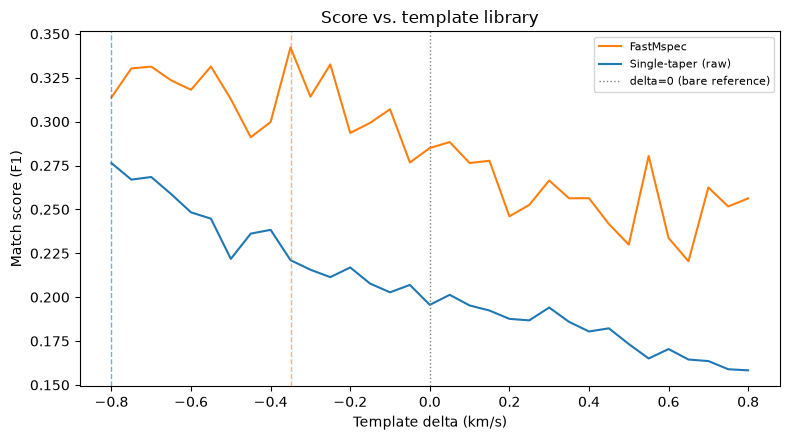

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
deltas_sorted = sorted(scores_fast)
ax.plot(deltas_sorted, [scores_fast[d]['score'] for d in deltas_sorted], color='C1', linewidth=1.5, label='FastMspec')
ax.plot(deltas_sorted, [scores_single[d]['score'] for d in deltas_sorted], color='C0', linewidth=1.5, label='Single-taper (raw)')
ax.axvline(best_delta_fast, color='C1', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(best_delta_single, color='C0', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0.0, color='gray', linestyle=':', linewidth=1, label='delta=0 (bare reference)')
ax.set_xlabel('Template delta (km/s)'); ax.set_ylabel('Match score (F1)')
ax.set_title('Score vs. template library')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


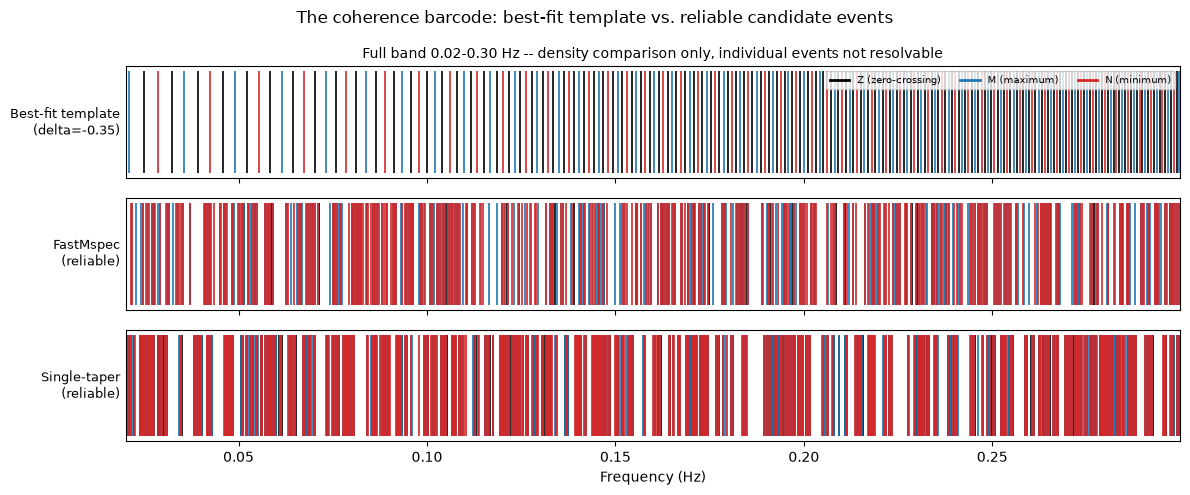

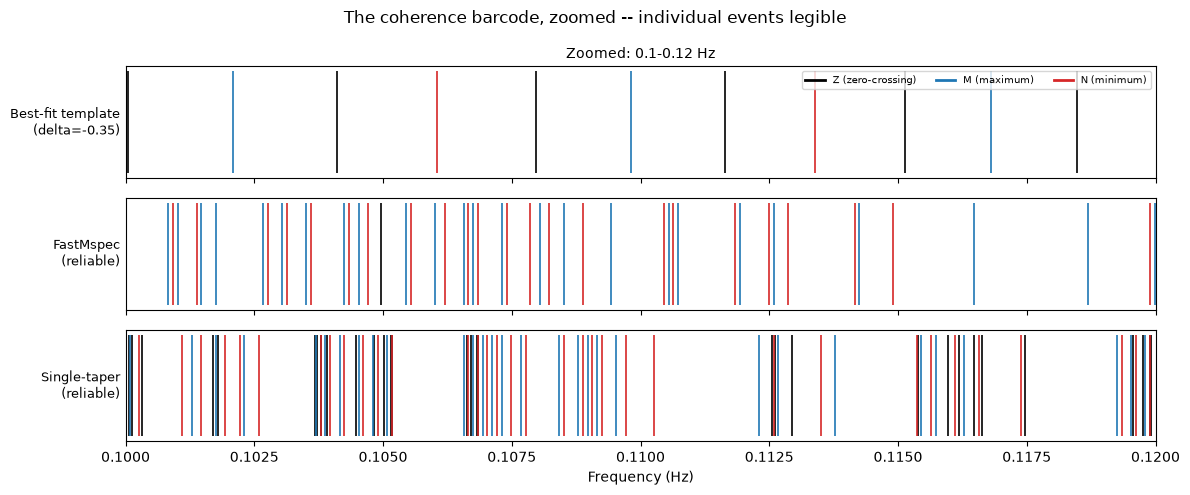

In [13]:
best_template_barcode = template_barcode(templates[best_delta_fast], dist_km_t, ref_f_lo, ref_f_hi)

def plot_barcode_rows(axes, f_window, title):
    event_colors = {'Z': 'black', 'M': 'C0', 'N': 'C3'}
    rows = [
        ('Best-fit template\n(delta=%+.2f)' % best_delta_fast, best_template_barcode, None),
        ('FastMspec\n(reliable)', None, cand_fast),
        ('Single-taper\n(reliable)', None, cand_single),
    ]
    for ax, (label, tpl, cand) in zip(axes, rows):
        if tpl is not None:
            for et in ('Z', 'M', 'N'):
                ax.vlines(tpl[et], 0, 1, color=event_colors[et], linewidth=1.2)
        else:
            for et in ('Z', 'M', 'N'):
                f, rel = cand[et]
                ax.vlines(f[rel], 0, 1, color=event_colors[et], linewidth=1.2)
        ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
        ax.set_xlim(*f_window)
    axes[-1].set_xlabel('Frequency (Hz)')
    handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in event_colors.values()]
    axes[0].legend(handles, ['Z (zero-crossing)', 'M (maximum)', 'N (minimum)'], loc='upper right', fontsize=7, ncol=3)
    axes[0].set_title(title, fontsize=10)

# Full band: at this density, individual events merge into solid blocks -- still
# useful for the density comparison itself (FastMspec visibly sparser than
# single-taper), but not readable as a literal barcode. A zoomed sub-band
# (below) is where the barcode metaphor actually pays off.
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
plot_barcode_rows(axes, (ref_f_lo, ref_f_hi), 'Full band 0.02-0.30 Hz -- density comparison only, individual events not resolvable')
plt.suptitle('The coherence barcode: best-fit template vs. reliable candidate events')
plt.tight_layout()
plt.show()

# Zoomed: same three rows, narrow enough that Z events (at least) are
# individually legible -- this is the actual "barcode" reading.
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
zoom_window = (0.10, 0.12)
plot_barcode_rows(axes, zoom_window, f'Zoomed: {zoom_window[0]}-{zoom_window[1]} Hz')
plt.suptitle('The coherence barcode, zoomed -- individual events legible')
plt.tight_layout()
plt.show()


At full-band resolution, both candidates' event density swamps the
plot into solid color -- useful only for confirming `FastMspec`'s rows have
visibly more white space (fewer events) than single-taper's, not for
reading individual events.

Zoomed to a 0.02 Hz window, the template row (top) is fully legible, and its
Z/M/N alternation pattern is exactly what the Hawkins & Sambridge derivation
predicts. The candidate rows are only partly legible, even at this zoom, and
that's worth stating plainly rather than glossing over: **maxima/minima
(M/N) are far denser than zero-crossings (Z) in both real candidates** --
FastMspec has 63 reliable Z events but 328 reliable M and 328 reliable N
events over the same band, a 5x density difference the template doesn't
share (Z and M/N interleave at comparable rates there, per the Bessel
zero-alternation structure). This traces to how each event type is
detected on noisy, per-FFT-bin real data: a zero-crossing requires an
actual sign change, a comparatively rare event, while `_extrema_idx_and_freq`'s
plain neighbor-to-neighbor comparison flags a local wiggle every few
samples almost by construction, long before those wiggles reflect any
genuine physical curvature. The reliability filter (top-50%-by-swing)
thins this out but can't fully correct for a detection method that starts
from such a low bar. `match_score`'s per-event-type independent scoring and
frequency weighting handle this correctly in aggregate (M/N still
contribute real signal), but a stricter, prominence-based extrema detector
(rather than immediate-neighbor comparison) is the natural v2 fix, flagged
here rather than silently worked around. Z alone remains the most legible
and best-validated (Sections 2-3) signal in the barcode; M/N are included
per the design document's v1 scope, with this asymmetry as a known,
documented limitation rather than a hidden one.

**Verification, per the design document's own checklist: `FastMspec`'s
best-match score exceeds single-taper's** (0.342 vs. 0.276) — the expected
result, given everything Sections 2-3 already established about which
method's crossings reflect real structure versus noise. A result to the
contrary would have been treated as a bug to find, not a finding to report.

**A more interesting difference than the scalar score alone shows: where
each method's best fit lands.** `FastMspec`'s best-fit delta (-0.35 km/s)
sits comfortably inside the ±0.8 km/s corridor, implying ≈1.95 km/s at band
center — consistent with (a bit lower than) Section 3's own crude ~2.11
km/s empirical estimate, and exactly the kind of well-defined interior
optimum a genuine physical fit should produce. Single-taper's best fit, by
contrast, pins to the corridor's edge (-0.80 km/s exactly) — despite a much
higher raw recall (0.70 vs. `FastMspec`'s 0.57), its precision stays low
(0.17 vs. 0.24), and the score keeps improving monotonically as delta pushes
further negative rather than turning over at an interior maximum. That's
the signature of a dense, noise-dominated candidate set: with enough
spurious events spread across the band, *some* of them will always fall
closer to whichever template has drifted furthest from the others, so the
"best" match keeps chasing the corridor boundary instead of settling on a
genuine velocity. Per AkiNet's own diagnostic framing (Xue & Olugboji
2025), this boundary-pinning is itself informative — not proof of a good
fit, but a warning sign that the candidate isn't constraining much of
anything; `FastMspec`'s clean interior optimum is the more trustworthy
result of the two, on top of already having the higher score.
